In [10]:
#%cd../
from src.data_loader import CoffeeDataset
from src.region_extraction import extract_region
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import torch
import pywt
from skimage.feature import graycomatrix


def get_center_image(x, window):
    h, w = x.shape[:2]
    h_c = h // 2
    w_c = w // 2
    offset = window // 2
    return x[h_c - offset:h_c + offset, w_c - offset:w_c + offset]


class TransformedDataset(CoffeeDataset):
    def __init__(self, split):
        self.window_size = 128  # center crop
        self.glcm_distances = [5, 10, 15, 25]
        self.glcm_angles = [0, 45, 90, 135]
        super().__init__(split, )
    
    def compute_statistics(self, x):
        normalized = x/255
        stats = np.concat([normalized.mean(axis=(0, 1)), normalized.std(axis=(0, 1))], axis=0)
        return stats
    
    def compute_haar(self, x):
        approx, maps = pywt.dwt2(x.mean(axis=-1), 'Db2')
        return np.stack(maps, axis=-1) / 10 # cannot normalize, amplitude is important
    
    def compute_glcm(self, x):
        glcm = graycomatrix((255*x.mean(axis=-1)).astype("uint8"), self.glcm_distances, self.glcm_angles)
        return glcm.reshape(256, 256, -1) # size of glcm is always 256x256 - number of pixel intensities
    
    def __getitem__(self, item):
        img, label = super().__getitem__(item)
        img = np.asarray(img)
        centered = get_center_image(img, self.window_size)
        wavelet = self.compute_haar(centered)
        stats = self.compute_statistics(centered)
        glcm = self.compute_glcm(centered)
        return wavelet, glcm, stats, label # (window, window, 3), (256,256,16), (6,), (1,)

(65, 65, 3)


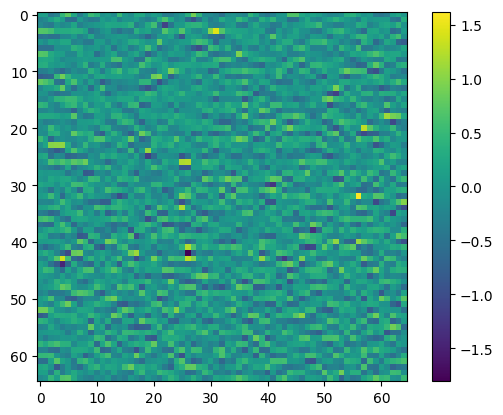

In [11]:
dataset = TransformedDataset("train")

img, glcm, stats, label = dataset[10]
print(img.shape)
plt.imshow(img[..., 0])
plt.colorbar()